## Evaluate the consistency and quality of sequences sampled by PEINT variants

In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
tqdm.pandas()

## Eval on test set donor 4 transitions

In [24]:
samples_dir = "../results/gen_eval"
ctmc_mat_exp_df = pd.read_csv(f"{samples_dir}/ctmc_mat_exp.csv")
ctmc_gillespie_df = pd.read_csv(f"{samples_dir}/ctmc_gillespie.csv")
peint_df = pd.read_csv(f"{samples_dir}/peint.csv")

In [37]:
# for each df, calculate the hamming distance between the real parent and the simulated child (for both heavy and light sequences)
def compute_hamming_distance(seq1, seq2):
    assert len(seq1) == len(seq2)
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

ctmc_mat_exp_df["hmd_hv"] = ctmc_mat_exp_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_hv"], row["sim_child_hv"]), axis=1)
ctmc_mat_exp_df["hmd_lt"] = ctmc_mat_exp_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_lt"], row["sim_child_lt"]), axis=1)
ctmc_gillespie_df["hmd_hv"] = ctmc_gillespie_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_hv"], row["sim_child_hv"]), axis=1)
ctmc_gillespie_df["hmd_lt"] = ctmc_gillespie_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_lt"], row["sim_child_lt"]), axis=1)
peint_df["hmd_hv"] = peint_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_hv"], row["sim_child_hv"]), axis=1)
peint_df["hmd_lt"] = peint_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_lt"], row["sim_child_lt"]), axis=1)
true_df = peint_df.copy()
true_df["hmd_hv"] = true_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_hv"], row["real_child_hv"]), axis=1)
true_df["hmd_lt"] = true_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_lt"], row["real_child_lt"]), axis=1)

100%|██████████| 1600/1600 [00:00<00:00, 76515.70it/s]


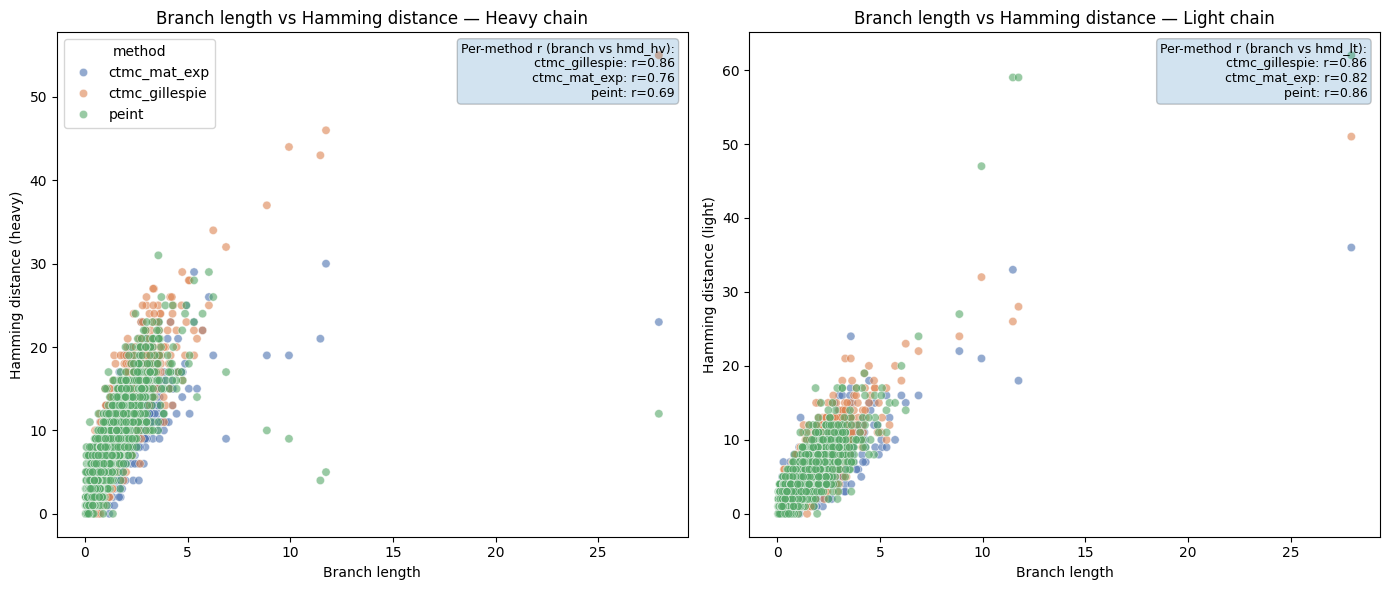

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

data = pd.concat([
    ctmc_mat_exp_df.assign(method="ctmc_mat_exp"),
    ctmc_gillespie_df.assign(method="ctmc_gillespie"),
    peint_df.assign(method="peint"),
    true_df.assign(method="data"),
])

sns.scatterplot(data=data, x="branch_length", y="hmd_hv", hue="method", alpha=0.6, ax=axes[0], palette="deep", legend="full")
axes[0].set_title("Branch length vs Hamming distance — Heavy chain")
axes[0].set_xlabel("Branch length")
axes[0].set_ylabel("Hamming distance (heavy)")

sns.scatterplot(data=data, x="branch_length", y="hmd_lt", hue="method", alpha=0.6, ax=axes[1], palette="deep", legend=False)
axes[1].set_title("Branch length vs Hamming distance — Light chain")
axes[1].set_xlabel("Branch length")
axes[1].set_ylabel("Hamming distance (light)")

# compute Pearson correlation coefficients (per-method and overall) and annotate
corrs_hv = data.groupby("method").apply(lambda g: g["branch_length"].corr(g["hmd_hv"]))
corrs_lt = data.groupby("method").apply(lambda g: g["branch_length"].corr(g["hmd_lt"]))
overall_hv = data["branch_length"].corr(data["hmd_hv"])
overall_lt = data["branch_length"].corr(data["hmd_lt"])

txt_hv = "Per-method r (branch vs hmd_hv):\n" + "\n".join(f"{m}: r={r:.2f}" for m, r in corrs_hv.items())
# txt_hv += f"\nOverall: r={overall_hv:.2f}"

txt_lt = "Per-method r (branch vs hmd_lt):\n" + "\n".join(f"{m}: r={r:.2f}" for m, r in corrs_lt.items())
# txt_lt += f"\nOverall: r={overall_lt:.2f}"

# place the r boxes on the top-right of each subplot
axes[0].text(0.98, 0.98, txt_hv, transform=axes[0].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))
axes[1].text(0.98, 0.98, txt_lt, transform=axes[1].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))

plt.tight_layout()
plt.show()

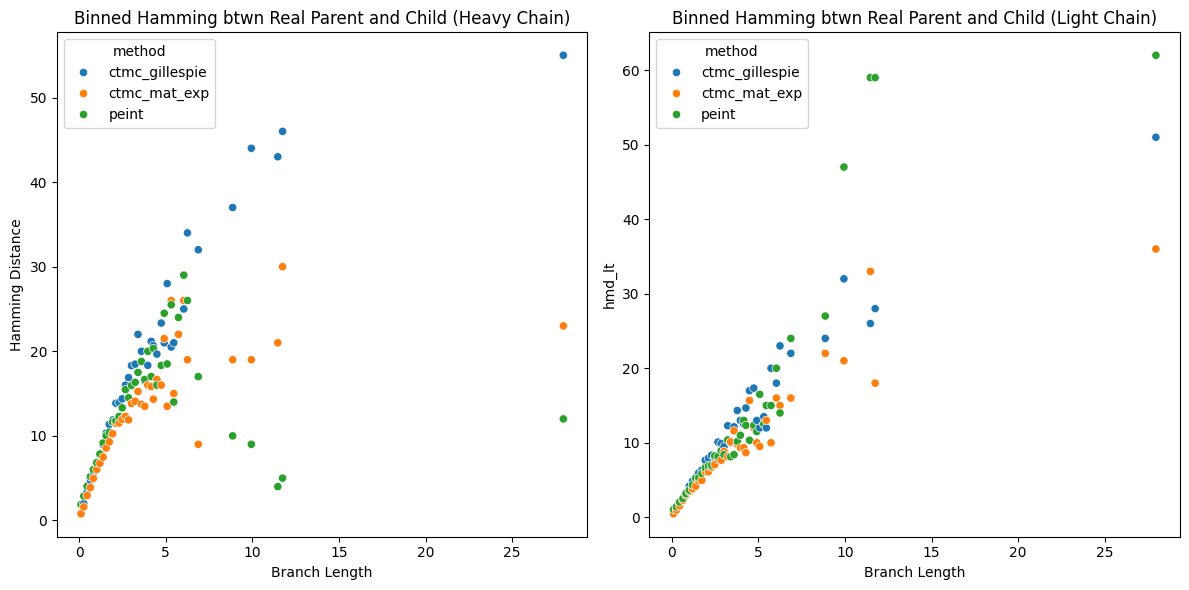

In [41]:
# do this plot again, but now bin by branch length
bl_quantile = data.branch_length.quantile(0.15)
data["bl_bin"] = data.branch_length.astype(float) // bl_quantile.astype(float)

cols_to_keep = ["hmd_hv", "hmd_lt", "method", "bl_bin", "branch_length"]
binned_hv_u = data[cols_to_keep].groupby(by=["bl_bin", "method"]).mean()
binned_lt_u = data[cols_to_keep].groupby(by=["bl_bin", "method"]).mean()
binned_hv_s = data[cols_to_keep].groupby(by=["bl_bin", "method"]).std()
binned_lt_s = data[cols_to_keep].groupby(by=["bl_bin", "method"]).std()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(data=binned_hv_u, x="branch_length", y="hmd_hv", hue="method", ax=ax[0], legend="full")
sns.scatterplot(data=binned_lt_u, x="branch_length", y="hmd_lt", hue="method", ax=ax[1], legend="full")

ax[0].set_title("Binned Hamming btwn Real Parent and Child (Heavy Chain)")
ax[1].set_title("Binned Hamming btwn Real Parent and Child (Light Chain)")
ax[0].set_xlabel("Branch Length")
ax[1].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[0].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()

In [28]:
# for each df, keep the rows with plddt scores and scatter plot plddt versus branch length
peint_plddt_vs_bl = peint_df.dropna(subset=["sim_child_hv_plddt", "sim_child_lt_plddt"])
gill_plddt_vs_bl = ctmc_gillespie_df.dropna(subset=["sim_child_hv_plddt", "sim_child_lt_plddt"])
matexp_plddt_vs_bl = ctmc_mat_exp_df.dropna(subset=["sim_child_hv_plddt", "sim_child_lt_plddt"])

## Eval on changing t for single parent sequence

In [32]:
samples_dir = "../results/gen_eval"
ctmc_mat_exp_df = pd.read_csv(f"{samples_dir}/ctmc_mat_exp_vary_t.csv")
ctmc_gillespie_df = pd.read_csv(f"{samples_dir}/ctmc_gillespie_vary_t.csv")
peint_df = pd.read_csv(f"{samples_dir}/peint_vary_t.csv")

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

data = pd.concat([
    ctmc_mat_exp_df.assign(method="ctmc_mat_exp"),
    ctmc_gillespie_df.assign(method="ctmc_gillespie"),
    peint_df.assign(method="peint")
])

sns.scatterplot(data=data, x="branch_lengths", y="hv_hmd", hue="method", alpha=0.6, ax=axes[0], palette="deep", legend="full")
axes[0].set_title("Branch length vs Hamming distance — Heavy chain")
axes[0].set_xlabel("Branch length")
axes[0].set_ylabel("Hamming distance (heavy)")

sns.scatterplot(data=data, x="branch_lengths", y="lt_hmd", hue="method", alpha=0.6, ax=axes[1], palette="deep", legend=False)
axes[1].set_title("Branch length vs Hamming distance — Light chain")
axes[1].set_xlabel("Branch length")
axes[1].set_ylabel("Hamming distance (light)")

# compute Pearson correlation coefficients (per-method and overall) and annotate
corrs_hv = data.groupby("method").apply(lambda g: g["branch_lengths"].corr(g["hv_hmd"]))
corrs_lt = data.groupby("method").apply(lambda g: g["branch_lengths"].corr(g["lt_hmd"]))
overall_hv = data["branch_lengths"].corr(data["hv_hmd"])
overall_lt = data["branch_lengths"].corr(data["lt_hmd"])

txt_hv = "Per-method r (branch vs hv_hmd):\n" + "\n".join(f"{m}: r={r:.2f}" for m, r in corrs_hv.items())
# txt_hv += f"\nOverall: r={overall_hv:.2f}"

txt_lt = "Per-method r (branch vs lt_hmd):\n" + "\n".join(f"{m}: r={r:.2f}" for m, r in corrs_lt.items())
# txt_lt += f"\nOverall: r={overall_lt:.2f}"

# place the r boxes on the top-right of each subplot
axes[0].text(0.98, 0.98, txt_hv, transform=axes[0].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))
axes[1].text(0.98, 0.98, txt_lt, transform=axes[1].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))

plt.tight_layout()
plt.show()

,branch_lengths,hv_par,lt_par,hv_seqs,lt_seqs,hv_hmd,lt_hmd
0,0.000000,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,0,0
1,0.505051,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGRSLRLSCAASGFTFSDYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,5,1
2,1.010101,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGRSLRLSCAASGFTFRNFGMHWVRQAPGKGLQ...,ENVLTQSPGTLSLSPGERATLSCRASQRVSSSYLSWYQQKPGQSPR...,8,6
3,1.515152,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGGSLRLSCAASGFSFSDCGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSNYLAWYQQKPGQAPR...,8,7
4,2.020202,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGGSLRLSCEASGFTFSNFGVNWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVISNYLAWYQQKPGQAPR...,15,7


In [47]:
# plot branch length vs plddt colored by method (heavy and light chain side by side)
# Filter rows with pLDDT scores
peint_plddt = peint_df.dropna(subset=["hv_seqs_plddt", "lt_seqs_plddt"])
gill_plddt = ctmc_gillespie_df.dropna(subset=["hv_seqs_plddt", "lt_seqs_plddt"])
matexp_plddt = ctmc_mat_exp_df.dropna(subset=["hv_seqs_plddt", "lt_seqs_plddt"])

# Combine data
plddt_data = pd.concat([
    peint_plddt.assign(method="peint"),
    gill_plddt.assign(method="ctmc_gillespie"),
    matexp_plddt.assign(method="ctmc_mat_exp")
])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Heavy chain
sns.scatterplot(
    data=plddt_data, 
    x="branch_lengths", 
    y="hv_seqs_plddt", 
    hue="method", 
    alpha=0.6, 
    ax=axes[0], 
    palette="deep", 
    legend="full"
)
axes[0].set_title("Branch Length vs pLDDT Score — Heavy Chain")
axes[0].set_xlabel("Branch Length")
axes[0].set_ylabel("pLDDT Score (Heavy)")

# Light chain
sns.scatterplot(
    data=plddt_data, 
    x="branch_lengths", 
    y="lt_seqs_plddt", 
    hue="method", 
    alpha=0.6, 
    ax=axes[1], 
    palette="deep", 
    legend=False
)
axes[1].set_title("Branch Length vs pLDDT Score — Light Chain")
axes[1].set_xlabel("Branch Length")
axes[1].set_ylabel("pLDDT Score (Light)")

# Compute Pearson correlation coefficients
corrs_hv = plddt_data.groupby("method").apply(lambda g: g["branch_lengths"].corr(g["hv_seqs_plddt"]))
corrs_lt = plddt_data.groupby("method").apply(lambda g: g["branch_lengths"].corr(g["lt_seqs_plddt"]))

txt_hv = "Per-method r (branch vs pLDDT_hv):\n" + "\n".join(f"{m}: r={r:.3f}" for m, r in corrs_hv.items())
txt_lt = "Per-method r (branch vs pLDDT_lt):\n" + "\n".join(f"{m}: r={r:.3f}" for m, r in corrs_lt.items())

# Place correlation annotations
axes[0].text(0.98, 0.02, txt_hv, transform=axes[0].transAxes, ha="right", va="bottom", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))
axes[1].text(0.98, 0.02, txt_lt, transform=axes[1].transAxes, ha="right", va="bottom", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))

plt.tight_layout()
plt.show()

In [47]:
peint_df.head()

,branch_lengths,hv_par,lt_par,hv_seqs,lt_seqs,hv_hmd,lt_hmd,hv_seqs_plddt,lt_seqs_plddt
0,0.000000,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,0,0,86.229152,89.645163
1,0.505051,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGRSLRLSCAASGFTFSDYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,5,1,85.996688,89.580253
2,1.010101,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGRSLRLSCAASGFTFRNFGMHWVRQAPGKGLQ...,ENVLTQSPGTLSLSPGERATLSCRASQRVSSSYLSWYQQKPGQSPR...,8,6,84.890544,89.373612
3,1.515152,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGGSLRLSCAASGFSFSDCGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSNYLAWYQQKPGQAPR...,8,7,83.995358,90.254089
4,2.020202,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGGSLRLSCEASGFTFSNFGVNWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVISNYLAWYQQKPGQAPR...,15,7,84.065222,89.573191


### Evaluate consistency of samples across time steps for each method

In [14]:
from peint.metrics.esm2 import compute_mmd, compare_threemer_distributions

In [15]:
samples_dir = "results/gen_eval"
ctmc_mat_exp_df = pd.read_csv(f"{samples_dir}/ctmc_mat_exp_step_size_samples.csv")
ctmc_gillespie_df = pd.read_csv(f"{samples_dir}/ctmc_gillespie_step_size_samples.csv")
peint_df = pd.read_csv(f"{samples_dir}/peint_step_size_samples.csv")

In [21]:
unique_step_sizes = peint_df["step_size"].unique()
unique_step_sizes.sort()
print(unique_step_sizes)

# for each method, calculate the num_step_size vs num_step_size array of mmd^2 values between each pair of step sizes
method_to_mmd2_hv_matrix = {}
method_to_mmd2_lt_matrix = {}
method_to_jsd_hv_matrix = {}
method_to_jsd_lt_matrix = {}

for method, df in [("ctmc_mat_exp", ctmc_mat_exp_df), ("ctmc_gillespie", ctmc_gillespie_df), ("peint", peint_df)]:
    mmd2_hv_matrix = np.zeros((len(unique_step_sizes), len(unique_step_sizes)))
    mmd2_lt_matrix = np.zeros((len(unique_step_sizes), len(unique_step_sizes)))
    jsd_hv_matrix = np.zeros((len(unique_step_sizes), len(unique_step_sizes)))
    jsd_lt_matrix = np.zeros((len(unique_step_sizes), len(unique_step_sizes)))
    
    for i, step_size_i in tqdm(enumerate(unique_step_sizes), total=len(unique_step_sizes), desc=f"Computing MMD^2 matrices for {method}"):
        seqs_i = df[df["step_size"] == step_size_i]["simulated_sequence"].tolist()
        seqs_i_hv, seqs_i_lt = zip(*[seq.split(".") for seq in seqs_i])
        for j, step_size_j in enumerate(unique_step_sizes):
            if i == j:
                mmd2_hv_matrix[i, j] = 0.0
                mmd2_lt_matrix[i, j] = 0.0
                jsd_hv_matrix[i, j] = 0.0
                jsd_lt_matrix[i, j] = 0.0
                continue
            if i > j:
                mmd2_hv_matrix[i, j] = mmd2_hv_matrix[j, i]
                mmd2_lt_matrix[i, j] = mmd2_lt_matrix[j, i]
                jsd_hv_matrix[i, j] = jsd_hv_matrix[j, i]
                jsd_lt_matrix[i, j] = jsd_lt_matrix[j, i]
                continue
            seqs_j_hv = df[df["step_size"] == step_size_j]["simulated_sequence"].tolist()
            seqs_j_hv, seqs_j_lt = zip(*[seq.split(".") for seq in seqs_j_hv])
            # mmd2_hv = compute_mmd(seqs_i_hv, seqs_j_hv)
            # mmd2_lt = compute_mmd(seqs_i_lt, seqs_j_lt)
            jsd_hv = compare_threemer_distributions(seqs_i_hv, seqs_j_hv)["cosine_similarity"]
            jsd_lt = compare_threemer_distributions(seqs_i_lt, seqs_j_lt)["cosine_similarity"]
            # mmd2_hv_matrix[i, j] = mmd2_hv
            # mmd2_lt_matrix[i, j] = mmd2_lt
            jsd_hv_matrix[i, j] = jsd_hv
            jsd_lt_matrix[i, j] = jsd_lt

    method_to_mmd2_hv_matrix[method] = mmd2_hv_matrix
    method_to_mmd2_lt_matrix[method] = mmd2_lt_matrix
    method_to_jsd_hv_matrix[method] = jsd_hv_matrix
    method_to_jsd_lt_matrix[method] = jsd_lt_matrix

[ 1.  2.  5. 10. 25. 50.]


Computing MMD^2 matrices for peint: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 18.48it/s]


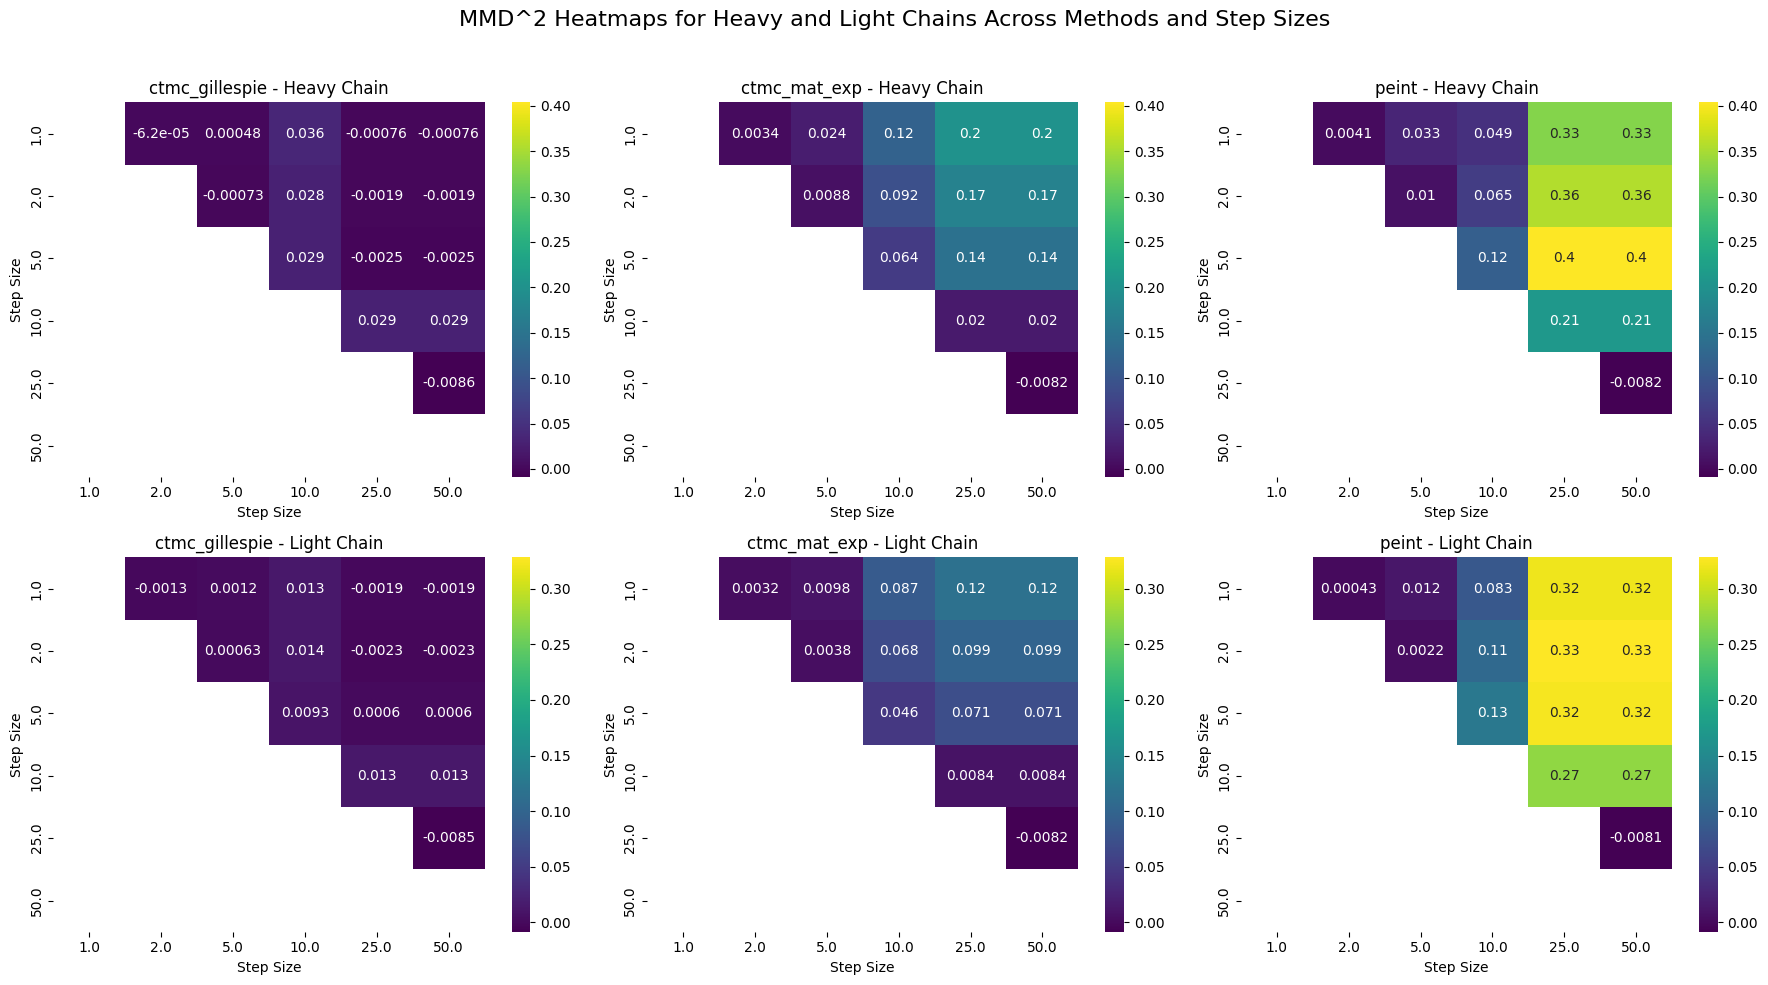

In [17]:
# plot 6 heatmaps (3 methods x 2 chains) of the mmd^2 matrices, use same color scale for heavy and light chains
# only plot upper triangle (since the matrices are symmetric) and diagnonal is 0

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
hv_vmin = min(matrix.min() for matrix in method_to_mmd2_hv_matrix.values())
hv_vmax = max(matrix.max() for matrix in method_to_mmd2_hv_matrix.values())
lt_vmin = min(matrix.min() for matrix in method_to_mmd2_lt_matrix.values())
lt_vmax = max(matrix.max() for matrix in method_to_mmd2_lt_matrix.values())

for col, method in enumerate(["ctmc_gillespie", "ctmc_mat_exp", "peint"]):
    sns.heatmap(
        method_to_mmd2_hv_matrix[method],
        ax=axes[0, col],
        xticklabels=unique_step_sizes,
        yticklabels=unique_step_sizes,
        vmin=hv_vmin,
        vmax=hv_vmax,
        cmap="viridis",
        annot=True,
        mask=np.tril(np.ones_like(method_to_mmd2_hv_matrix[method], dtype=bool))
    )
    axes[0, col].set_title(f"{method} - Heavy Chain")
    axes[0, col].set_xlabel("Step Size")
    axes[0, col].set_ylabel("Step Size")

    sns.heatmap(
        method_to_mmd2_lt_matrix[method],
        ax=axes[1, col],
        xticklabels=unique_step_sizes,
        yticklabels=unique_step_sizes,
        vmin=lt_vmin,
        vmax=lt_vmax,
        cmap="viridis",
        annot=True,
        mask=np.tril(np.ones_like(method_to_mmd2_lt_matrix[method], dtype=bool))
    )
    axes[1, col].set_title(f"{method} - Light Chain")
    axes[1, col].set_xlabel("Step Size")
    axes[1, col].set_ylabel("Step Size")

plt.suptitle("MMD^2 Heatmaps for Heavy and Light Chains Across Methods and Step Sizes", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

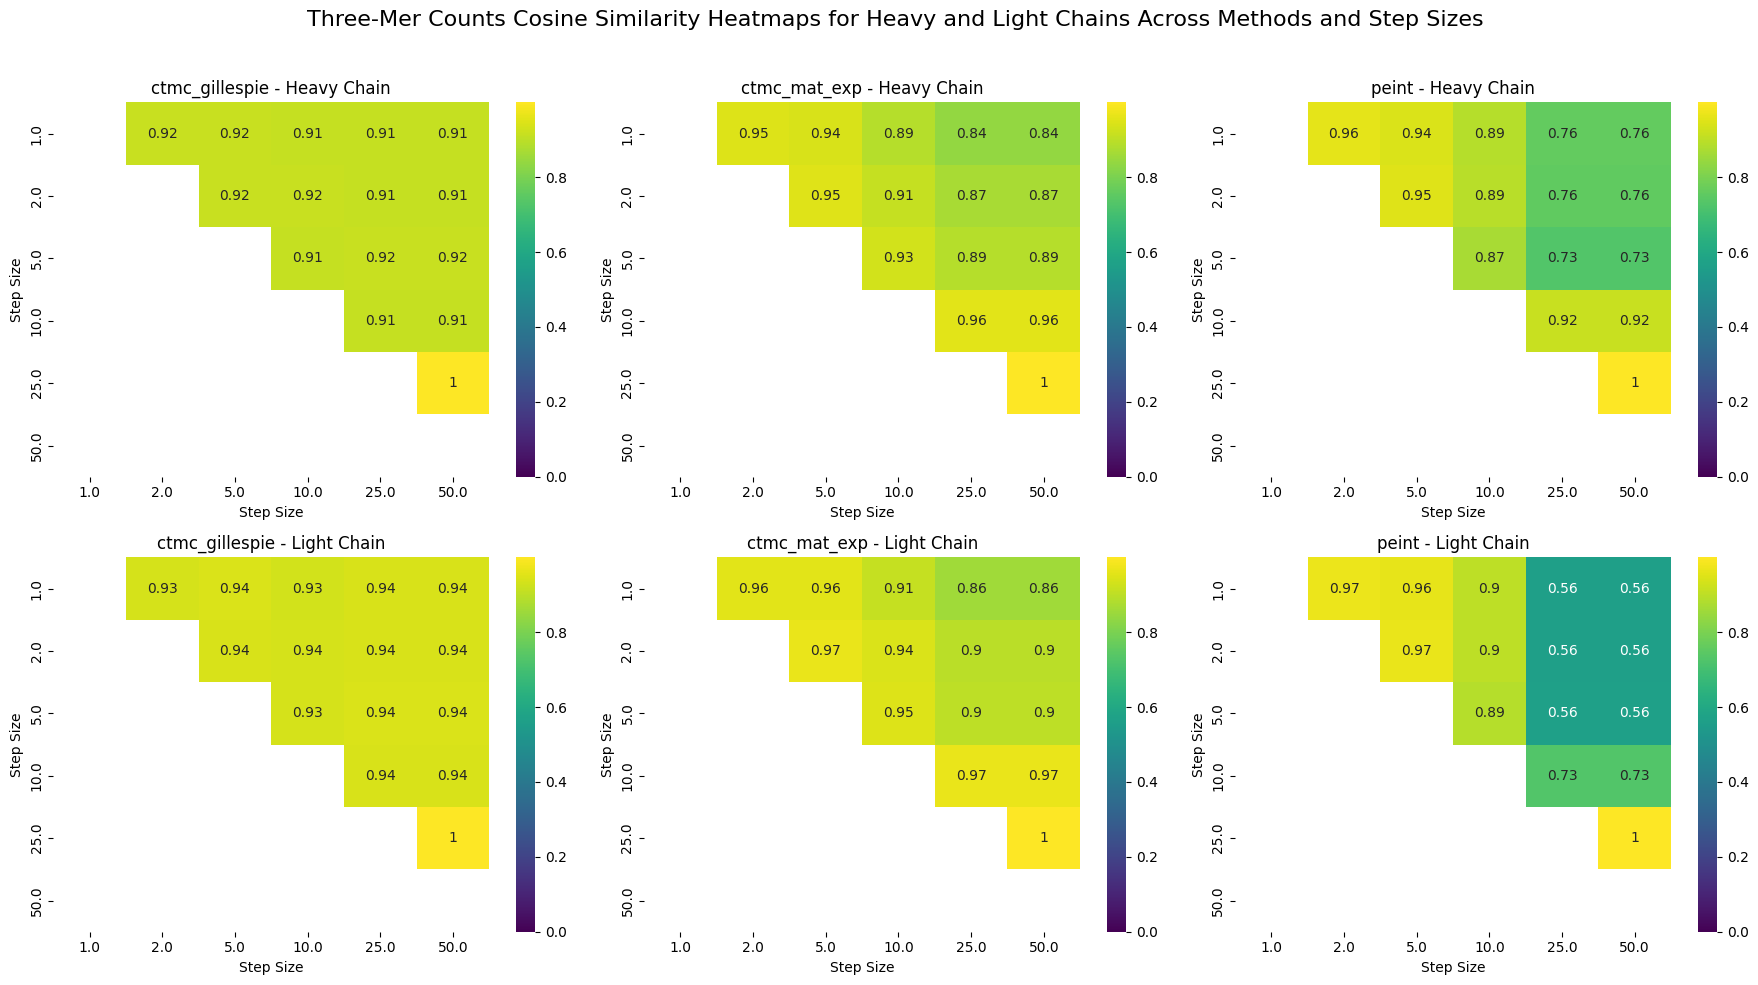

In [23]:
# plot 6 heatmaps (3 methods x 2 chains) of the JSD matrices, use same color scale for heavy and light chains
# only plot upper triangle (since the matrices are symmetric) and diagnonal is 0

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
hv_vmin = min(matrix.min() for matrix in method_to_jsd_hv_matrix.values())
hv_vmax = max(matrix.max() for matrix in method_to_jsd_hv_matrix.values())
lt_vmin = min(matrix.min() for matrix in method_to_jsd_lt_matrix.values())
lt_vmax = max(matrix.max() for matrix in method_to_jsd_lt_matrix.values())

for col, method in enumerate(["ctmc_gillespie", "ctmc_mat_exp", "peint"]):
    sns.heatmap(
        method_to_jsd_hv_matrix[method],
        ax=axes[0, col],
        xticklabels=unique_step_sizes,
        yticklabels=unique_step_sizes,
        vmin=hv_vmin,
        vmax=hv_vmax,
        cmap="viridis",
        annot=True,
        mask=np.tril(np.ones_like(method_to_jsd_hv_matrix[method], dtype=bool))
    )
    axes[0, col].set_title(f"{method} - Heavy Chain")
    axes[0, col].set_xlabel("Step Size")
    axes[0, col].set_ylabel("Step Size")

    sns.heatmap(
        method_to_jsd_lt_matrix[method],
        ax=axes[1, col],
        xticklabels=unique_step_sizes,
        yticklabels=unique_step_sizes,
        vmin=lt_vmin,
        vmax=lt_vmax,
        cmap="viridis",
        annot=True,
        mask=np.tril(np.ones_like(method_to_jsd_lt_matrix[method], dtype=bool))
    )
    axes[1, col].set_title(f"{method} - Light Chain")
    axes[1, col].set_xlabel("Step Size")
    axes[1, col].set_ylabel("Step Size")
    
plt.suptitle("Three-Mer Counts Cosine Similarity Heatmaps for Heavy and Light Chains Across Methods and Step Sizes", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()